# LSTM vs XGBoost — Model-wise KPI Comparison

This notebook provides a **head-to-head comparison** of the LSTM and XGBoost (Boosting) models on Japan (Tohoku region) electricity spot price forecasting.

> **Comparison period:** February 2026 — the only period where **both models** have forecast data.

**KPIs compared:**
| Metric | Description |
|--------|-------------|
| MAE | Mean Absolute Error — average magnitude of forecast error |
| RMSE | Root Mean Squared Error — penalises large errors more |
| SMAPE | Symmetric Mean Absolute Percentage Error (%) — scale-independent |

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# Consistent colours throughout
COLORS = {
    'actual':  '#2ca02c',
    'lstm':    '#1f77b4',
    'xgboost': '#d62728',
}

print('Libraries loaded.')

Libraries loaded.


## 2. Load Data

In [2]:
DATA_PATH = "KPI/boosting"

daily_kpis      = pd.read_csv(f"{DATA_PATH}/daily_kpis.csv", parse_dates=["date"])
monthly_kpis    = pd.read_csv(f"{DATA_PATH}/monthly_kpis.csv")
actual_forecast = pd.read_csv(f"{DATA_PATH}/actual_forecast.csv", parse_dates=["datetime"])

# Rows where BOTH XGBoost and LSTM have data
af_both = actual_forecast.dropna(subset=["xgboost_forecast", "lstm_forecast"]).copy()

print(f"Data loaded from            : {DATA_PATH}")
print(f"Total 30-min intervals      : {len(actual_forecast)}")
print(f"Intervals with both forecasts: {len(af_both)}")
print(f"Missing XGBoost rows        : {actual_forecast['xgboost_forecast'].isna().sum()}")
print(f"Missing LSTM rows           : {actual_forecast['lstm_forecast'].isna().sum()}")
print()
display(daily_kpis.head())

Data loaded from            : KPI/boosting
Total 30-min intervals      : 4369
Intervals with both forecasts: 3745
Missing XGBoost rows        : 624
Missing LSTM rows           : 0



,date,xgboost_mae,xgboost_rmse,xgboost_smape,lightgbm_mae,lightgbm_rmse,lightgbm_smape,gradient_boosting_mae,gradient_boosting_rmse,gradient_boosting_smape,catboost_mae,catboost_rmse,catboost_smape,adaboost_mae,adaboost_rmse,adaboost_smape,lstm_mae,lstm_rmse,lstm_smape
0,2025-11-01,2.536555,3.213339,23.282749,1.859683,2.437978,18.525337,2.638027,3.681220,23.157062,1.870679,2.596900,17.973013,1.944106,2.224017,19.072569,2.862083,3.624436,26.452763
1,2025-11-02,2.375910,3.585809,28.219934,1.907805,3.141372,25.121816,2.076721,3.159882,26.027886,1.860032,2.917620,24.571487,2.234518,2.958831,27.933442,1.885000,2.495866,25.269738
2,2025-11-03,0.662278,0.831082,6.446130,1.067686,1.273868,11.009749,0.742263,0.970877,7.686366,0.907841,1.284508,9.717924,1.075883,1.296112,9.493868,1.544792,1.785414,17.099124
3,2025-11-04,1.373725,2.023094,14.946021,1.855470,2.344333,18.919357,1.489896,2.062726,15.701266,1.584565,1.950251,16.296564,1.507526,1.878520,15.051572,1.439167,1.978464,15.580679
4,2025-11-05,0.673290,0.958558,6.440408,1.030821,1.281987,9.800658,0.776870,1.010163,7.537351,1.106239,1.346211,10.426760,1.255555,1.493355,11.861884,1.039792,1.235834,10.043238


## 3. Monthly KPI — Side-by-Side Table

In [3]:
comparison_table = pd.DataFrame({
    'Model':  ['XGBoost', 'LSTM'],
    'MAE':    [monthly_kpis['xgboost_mae'].values[0],   monthly_kpis['lstm_mae'].values[0]],
    'RMSE':   [monthly_kpis['xgboost_rmse'].values[0],  monthly_kpis['lstm_rmse'].values[0]],
    'SMAPE%': [monthly_kpis['xgboost_smape'].values[0], monthly_kpis['lstm_smape'].values[0]],
})

comparison_table = comparison_table.set_index('Model').round(4)

print('=== Monthly KPI Comparison (Feb 2026) ===')
display(comparison_table)

# Which model wins each metric?
print('\n=== Winner by Metric (lower is better) ===')
for col in comparison_table.columns:
    winner = comparison_table[col].idxmin()
    diff   = comparison_table[col].max() - comparison_table[col].min()
    print(f'  {col:8s}: {winner}  (margin = {diff:.4f})')

=== Monthly KPI Comparison (Feb 2026) ===


,MAE,RMSE,SMAPE%
Model,,,
XGBoost,1.7036,2.3474,17.9463
LSTM,1.5094,2.1140,16.7744



=== Winner by Metric (lower is better) ===
  MAE     : LSTM  (margin = 0.1942)
  RMSE    : LSTM  (margin = 0.2334)
  SMAPE%  : LSTM  (margin = 1.1719)


## 4. Actual vs Both Model Forecasts — Full Timeline

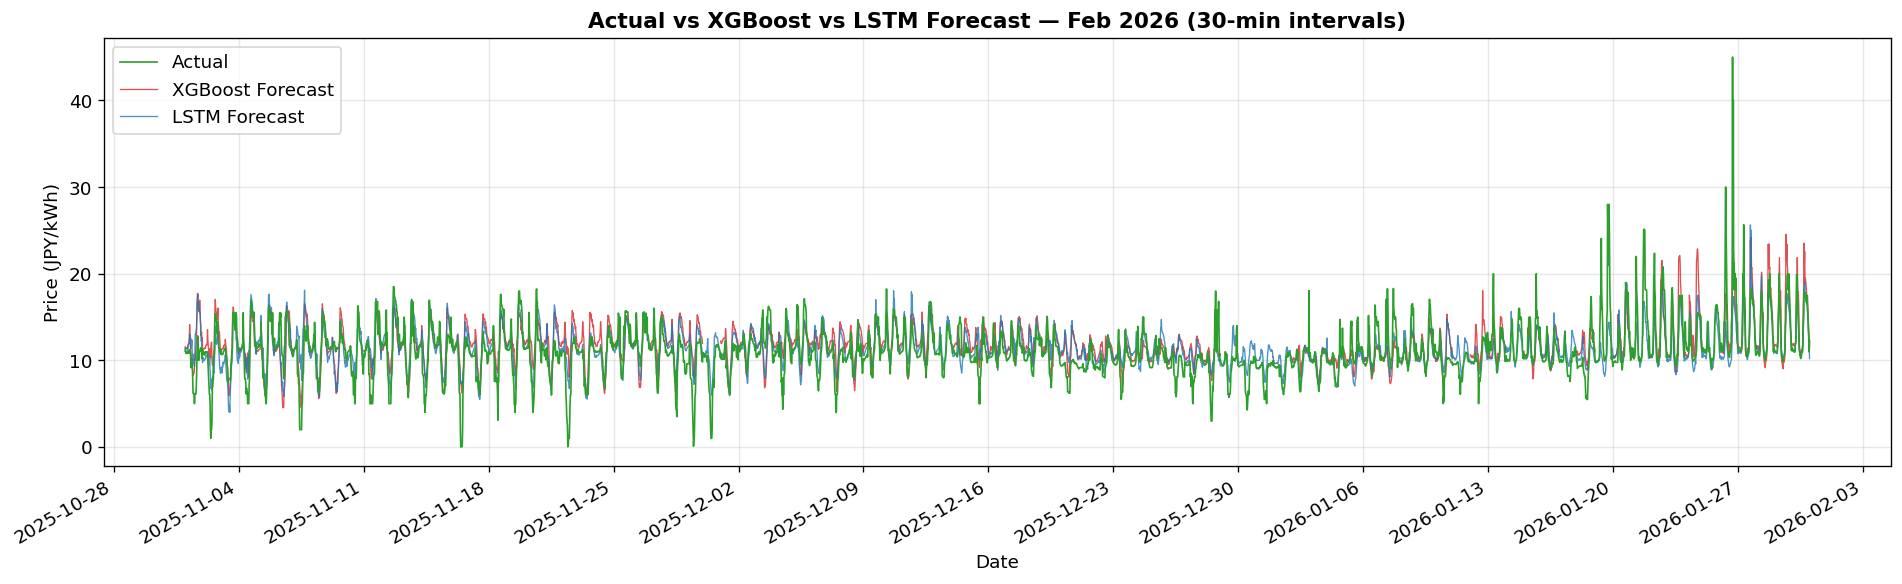

Plot saved.


In [4]:
fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(actual_forecast['datetime'], actual_forecast['actual_value'],
        label='Actual', color=COLORS['actual'], linewidth=1.0, zorder=3)
ax.plot(actual_forecast['datetime'], actual_forecast['xgboost_forecast'],
        label='XGBoost Forecast', color=COLORS['xgboost'], linewidth=0.8, alpha=0.8, zorder=2)
ax.plot(actual_forecast['datetime'], actual_forecast['lstm_forecast'],
        label='LSTM Forecast', color=COLORS['lstm'], linewidth=0.8, alpha=0.8, zorder=2)

ax.set_title('Actual vs XGBoost vs LSTM Forecast — Feb 2026 (30-min intervals)', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price (JPY/kWh)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
fig.autofmt_xdate()
ax.legend()
plt.tight_layout()
plt.savefig('KPI/comparison_actual_vs_both_forecasts.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved.')

## 5. Daily KPI Comparison — MAE, RMSE, SMAPE

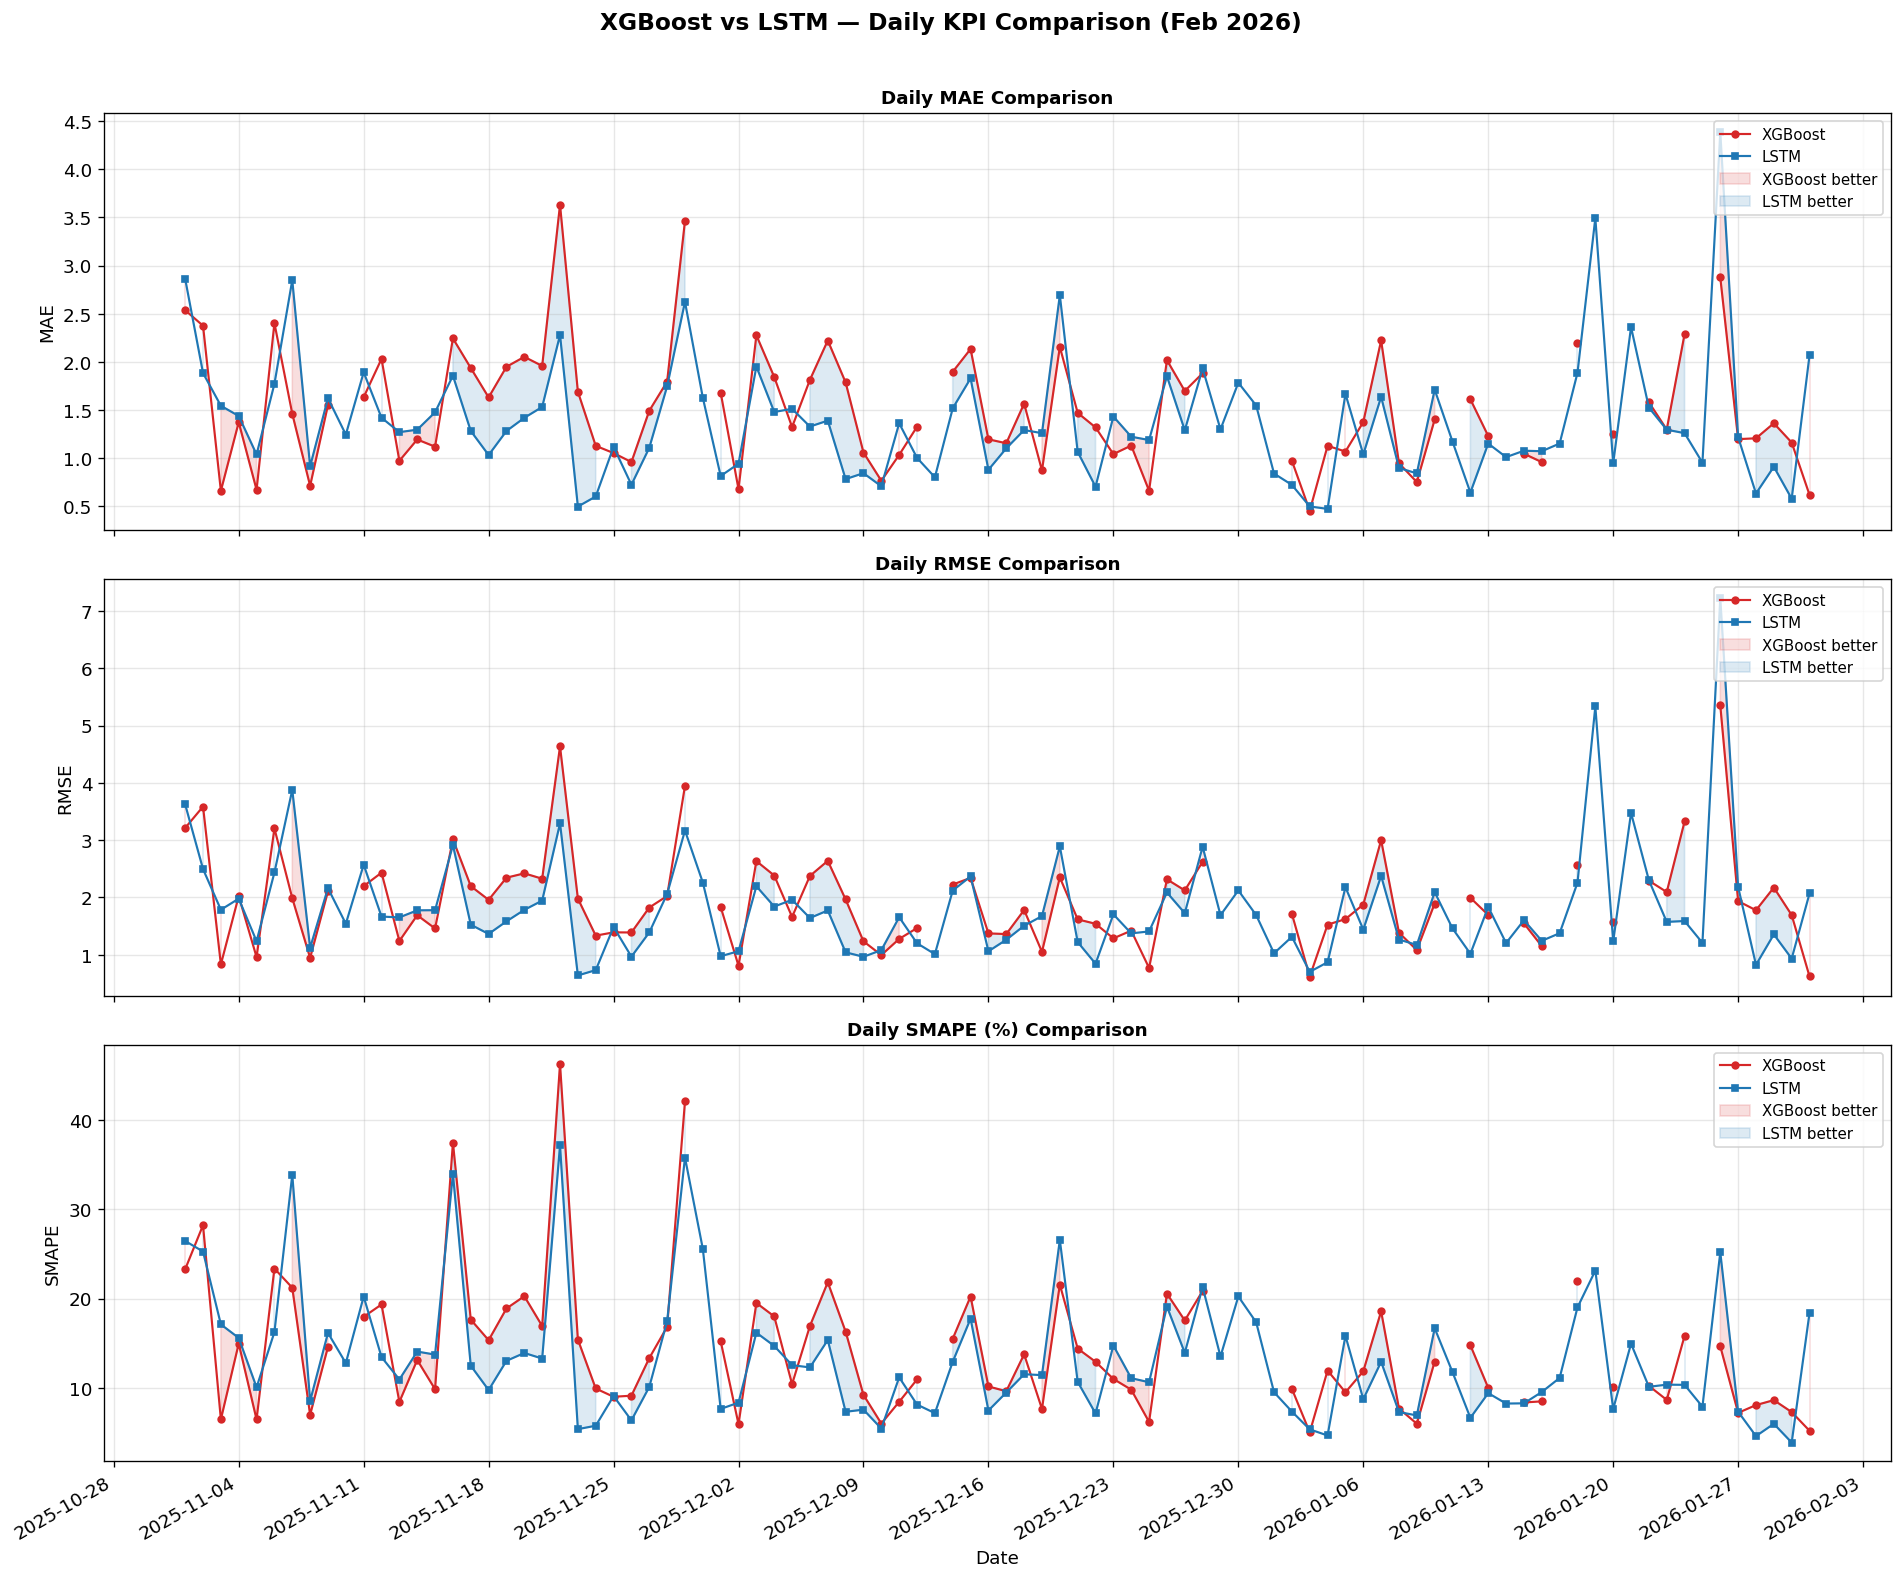

Plot saved.


In [5]:
fig, axes = plt.subplots(3, 1, figsize=(16, 13), sharex=True)

pairs = [
    ('xgboost_mae',   'lstm_mae',   'Daily MAE Comparison'),
    ('xgboost_rmse',  'lstm_rmse',  'Daily RMSE Comparison'),
    ('xgboost_smape', 'lstm_smape', 'Daily SMAPE (%) Comparison'),
]

for ax, (xgb_col, lstm_col, title) in zip(axes, pairs):
    ax.plot(daily_kpis['date'], daily_kpis[xgb_col],
            label='XGBoost', color=COLORS['xgboost'], linewidth=1.3,
            marker='o', markersize=4)
    ax.plot(daily_kpis['date'], daily_kpis[lstm_col],
            label='LSTM', color=COLORS['lstm'], linewidth=1.3,
            marker='s', markersize=4)
    # Shaded area showing which model is better each day
    ax.fill_between(daily_kpis['date'],
                    daily_kpis[xgb_col], daily_kpis[lstm_col],
                    where=daily_kpis[xgb_col] < daily_kpis[lstm_col],
                    alpha=0.15, color=COLORS['xgboost'], label='XGBoost better')
    ax.fill_between(daily_kpis['date'],
                    daily_kpis[xgb_col], daily_kpis[lstm_col],
                    where=daily_kpis[lstm_col] < daily_kpis[xgb_col],
                    alpha=0.15, color=COLORS['lstm'], label='LSTM better')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel(xgb_col.split('_')[-1].upper())
    ax.legend(fontsize=9, loc='upper right')

axes[-1].set_xlabel('Date')
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
axes[-1].xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
fig.autofmt_xdate()
fig.suptitle('XGBoost vs LSTM — Daily KPI Comparison (Feb 2026)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('KPI/comparison_daily_kpis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved.')

## 6. Win-Rate Analysis — Which Model is Better Each Day?

In [6]:
valid = daily_kpis.dropna(subset=['xgboost_mae', 'lstm_mae']).copy()

valid['mae_winner']   = np.where(valid['xgboost_mae']   < valid['lstm_mae'],   'XGBoost', 'LSTM')
valid['rmse_winner']  = np.where(valid['xgboost_rmse']  < valid['lstm_rmse'],  'XGBoost', 'LSTM')
valid['smape_winner'] = np.where(valid['xgboost_smape'] < valid['lstm_smape'], 'XGBoost', 'LSTM')

print('=== Daily Win-Rate (lower metric = winner) ===')
for metric in ['mae', 'rmse', 'smape']:
    col = f'{metric}_winner'
    counts = valid[col].value_counts()
    total  = len(valid)
    print(f'  {metric.upper():6s}: XGBoost wins {counts.get("XGBoost", 0):2d}/{total} days '
          f'({counts.get("XGBoost", 0)/total*100:.1f}%)   '
          f'LSTM wins {counts.get("LSTM", 0):2d}/{total} days '
          f'({counts.get("LSTM", 0)/total*100:.1f}%)')

=== Daily Win-Rate (lower metric = winner) ===
  MAE   : XGBoost wins 30/79 days (38.0%)   LSTM wins 49/79 days (62.0%)
  RMSE  : XGBoost wins 33/79 days (41.8%)   LSTM wins 46/79 days (58.2%)
  SMAPE : XGBoost wins 31/79 days (39.2%)   LSTM wins 48/79 days (60.8%)


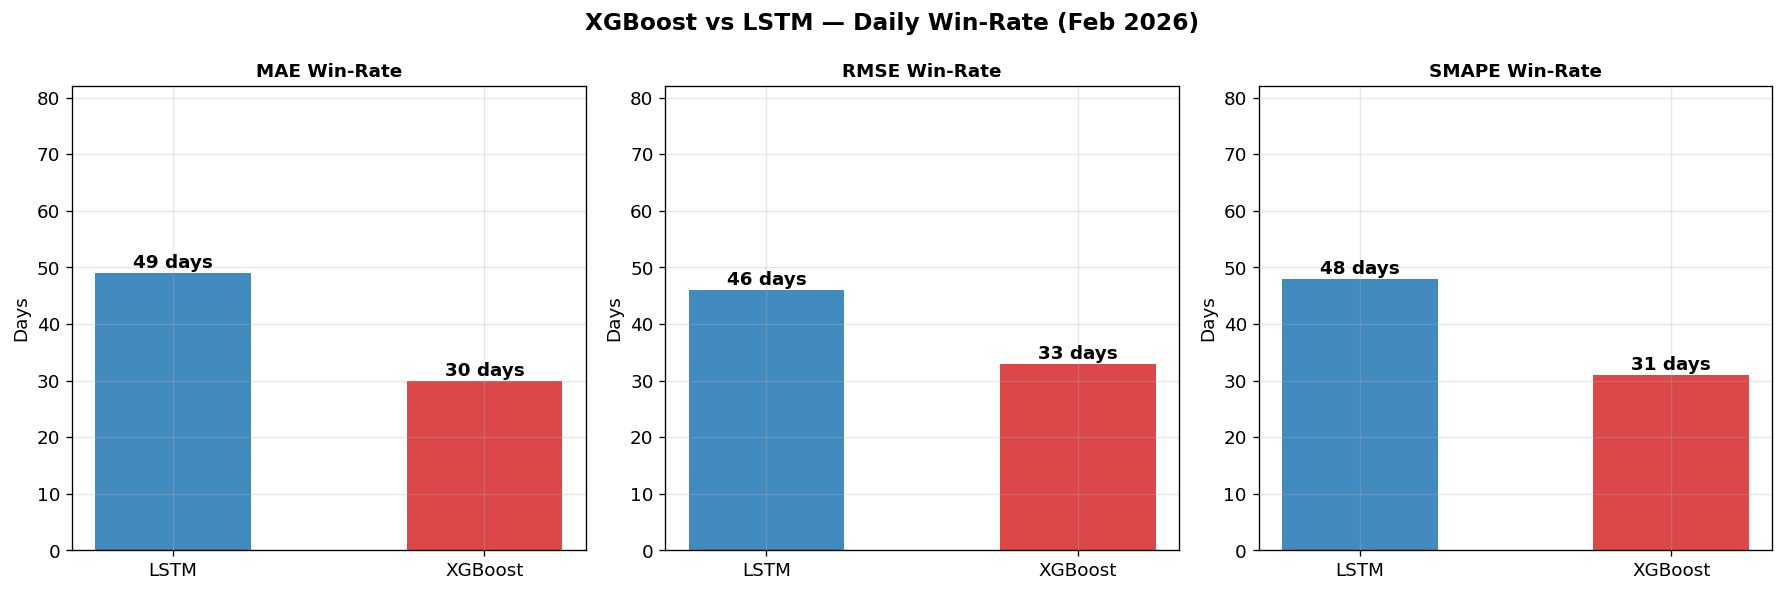

Plot saved.


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics_labels = ['MAE', 'RMSE', 'SMAPE']
winner_cols = ['mae_winner', 'rmse_winner', 'smape_winner']

for ax, metric, col in zip(axes, metrics_labels, winner_cols):
    counts = valid[col].value_counts()
    bars = ax.bar(counts.index, counts.values,
                  color=[COLORS.get(m.lower(), '#999') for m in counts.index],
                  alpha=0.85, width=0.5)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                f'{val} days', ha='center', va='bottom', fontweight='bold')
    ax.set_title(f'{metric} Win-Rate', fontsize=11, fontweight='bold')
    ax.set_ylabel('Days')
    ax.set_ylim(0, len(valid) + 3)

fig.suptitle('XGBoost vs LSTM — Daily Win-Rate (Feb 2026)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('KPI/comparison_win_rate.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved.')

## 7. Error Distribution Comparison

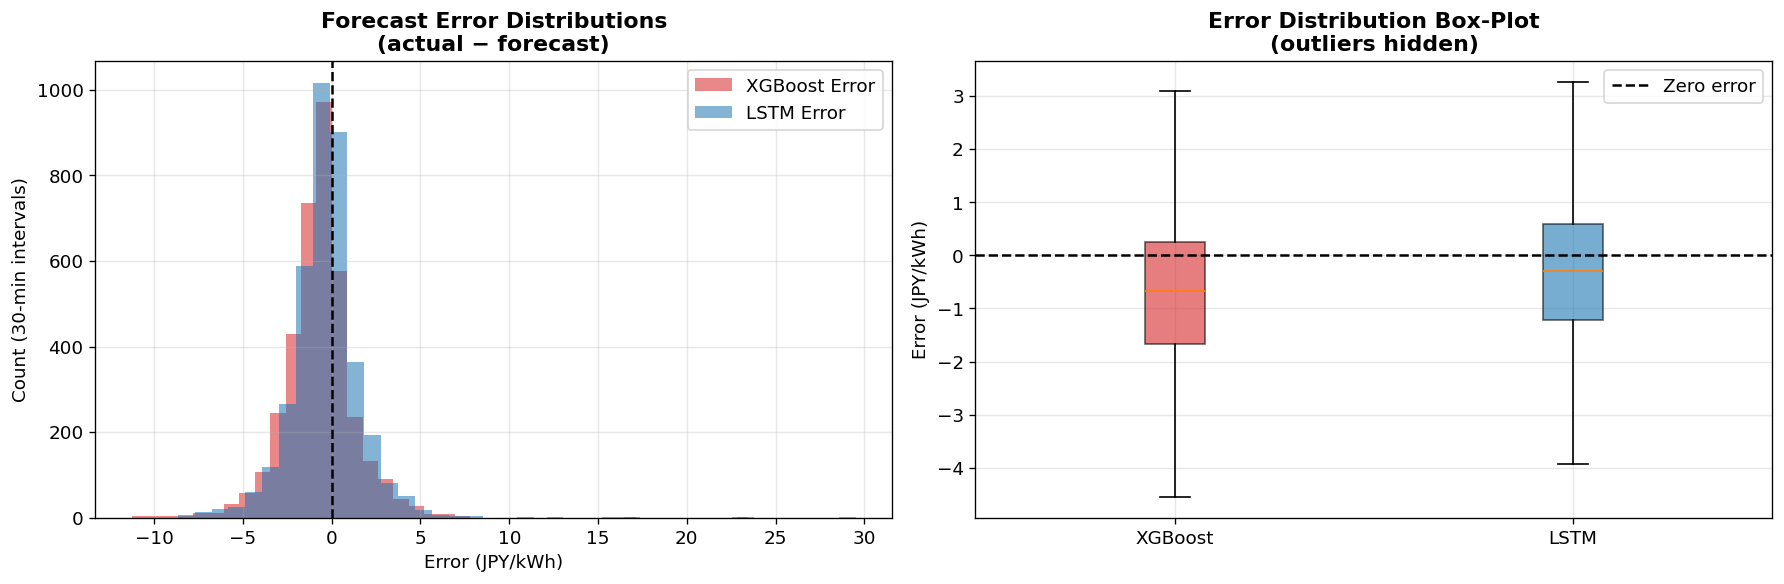

Plot saved.


In [8]:
af_both = actual_forecast.dropna(subset=['xgboost_forecast', 'lstm_forecast']).copy()
af_both['xgb_error']  = af_both['actual_value'] - af_both['xgboost_forecast']
af_both['lstm_error'] = af_both['actual_value'] - af_both['lstm_forecast']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Overlapping error histograms ─────────────────────────────────────────────
ax = axes[0]
ax.hist(af_both['xgb_error'],  bins=40, alpha=0.55, color=COLORS['xgboost'], label='XGBoost Error')
ax.hist(af_both['lstm_error'], bins=40, alpha=0.55, color=COLORS['lstm'],    label='LSTM Error')
ax.axvline(0, color='black', linewidth=1.5, linestyle='--')
ax.set_title('Forecast Error Distributions\n(actual − forecast)', fontweight='bold')
ax.set_xlabel('Error (JPY/kWh)')
ax.set_ylabel('Count (30-min intervals)')
ax.legend()

# ── Box plot comparison ───────────────────────────────────────────────────────
ax = axes[1]
bp = ax.boxplot(
    [af_both['xgb_error'].dropna(), af_both['lstm_error'].dropna()],
    labels=['XGBoost', 'LSTM'],
    patch_artist=True,
    showfliers=False
)
bp['boxes'][0].set_facecolor(COLORS['xgboost'])
bp['boxes'][0].set_alpha(0.6)
bp['boxes'][1].set_facecolor(COLORS['lstm'])
bp['boxes'][1].set_alpha(0.6)
ax.axhline(0, color='black', linewidth=1.5, linestyle='--', label='Zero error')
ax.set_title('Error Distribution Box-Plot\n(outliers hidden)', fontweight='bold')
ax.set_ylabel('Error (JPY/kWh)')
ax.legend()

plt.tight_layout()
plt.savefig('KPI/comparison_error_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved.')

## 8. Scatter: Model MAE Correlation Day-by-Day

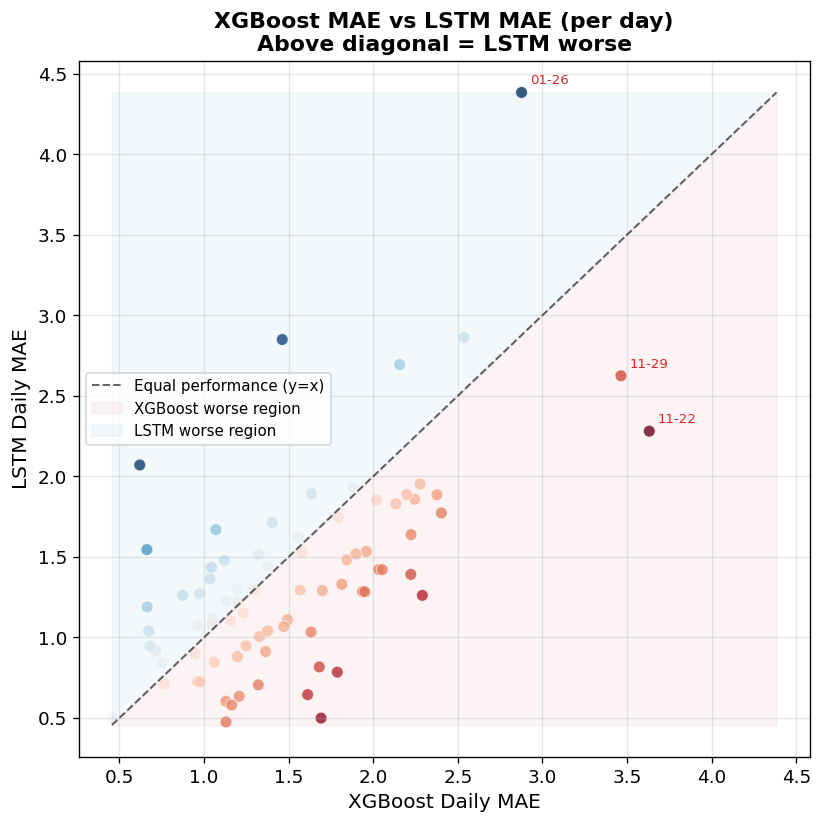

Plot saved.


In [9]:
valid = daily_kpis.dropna(subset=['xgboost_mae', 'lstm_mae'])

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(valid['xgboost_mae'], valid['lstm_mae'],
           c=valid['xgboost_mae'] - valid['lstm_mae'],
           cmap='RdBu_r', s=50, alpha=0.8, edgecolors='white', linewidth=0.5)

# Diagonal y=x
lims = [min(valid[['xgboost_mae', 'lstm_mae']].min()), max(valid[['xgboost_mae', 'lstm_mae']].max())]
ax.plot(lims, lims, 'k--', linewidth=1.2, alpha=0.6, label='Equal performance (y=x)')
ax.fill_between(lims, lims, [lims[0]] * 2, alpha=0.05, color=COLORS['xgboost'], label='XGBoost worse region')
ax.fill_between(lims, lims, [lims[1]] * 2, alpha=0.05, color=COLORS['lstm'],    label='LSTM worse region')

# Annotate worst days
for _, row in valid.nlargest(3, 'xgboost_mae').iterrows():
    ax.annotate(f"{row['date'].strftime('%m-%d')}",
                (row['xgboost_mae'], row['lstm_mae']),
                textcoords='offset points', xytext=(5, 5), fontsize=8, color=COLORS['xgboost'])

ax.set_xlabel('XGBoost Daily MAE', fontsize=12)
ax.set_ylabel('LSTM Daily MAE', fontsize=12)
ax.set_title('XGBoost MAE vs LSTM MAE (per day)\nAbove diagonal = LSTM worse', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('KPI/comparison_mae_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved.')

## 9. Radar / Spider Chart — Overall Metric Comparison

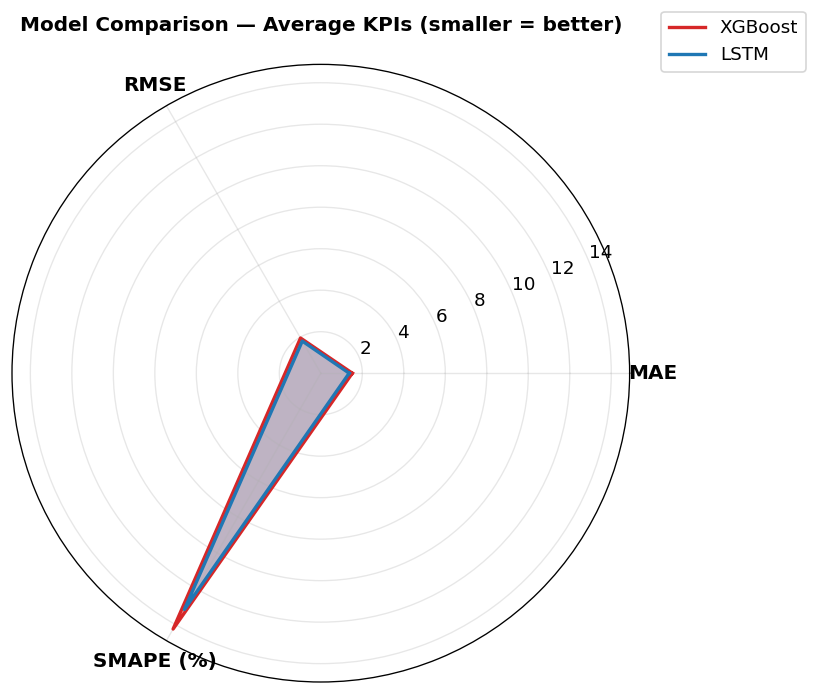

Plot saved.


In [10]:
from matplotlib.patches import FancyArrowPatch

valid = daily_kpis.dropna(subset=['xgboost_mae', 'lstm_mae'])

categories = ['MAE', 'RMSE', 'SMAPE (%)']
xgb_vals   = [
    valid['xgboost_mae'].mean(),
    valid['xgboost_rmse'].mean(),
    valid['xgboost_smape'].mean(),
]
lstm_vals  = [
    valid['lstm_mae'].mean(),
    valid['lstm_rmse'].mean(),
    valid['lstm_smape'].mean(),
]

N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]          # close the polygon
xgb_vals  += xgb_vals[:1]
lstm_vals += lstm_vals[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={'polar': True})
ax.plot(angles, xgb_vals,  color=COLORS['xgboost'], linewidth=2, linestyle='solid', label='XGBoost')
ax.fill(angles, xgb_vals,  alpha=0.25, color=COLORS['xgboost'])
ax.plot(angles, lstm_vals, color=COLORS['lstm'],    linewidth=2, linestyle='solid', label='LSTM')
ax.fill(angles, lstm_vals, alpha=0.25, color=COLORS['lstm'])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12, fontweight='bold')
ax.set_title('Model Comparison — Average KPIs (smaller = better)', fontsize=12, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.savefig('KPI/comparison_radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved.')

## 10. Comprehensive Summary Table

In [11]:
valid = daily_kpis.dropna(subset=['xgboost_mae', 'lstm_mae'])
af_both = actual_forecast.dropna(subset=['xgboost_forecast', 'lstm_forecast']).copy()
af_both['xgb_error']  = af_both['actual_value'] - af_both['xgboost_forecast']
af_both['lstm_error'] = af_both['actual_value'] - af_both['lstm_forecast']

summary = pd.DataFrame({
    'Metric': [
        'Avg Daily MAE',
        'Avg Daily RMSE',
        'Avg Daily SMAPE (%)',
        'Monthly MAE',
        'Monthly RMSE',
        'Monthly SMAPE (%)',
        'Forecast Bias (mean error)',
        'Std Dev of Error',
        'Days as Winner (MAE)',
        'Days as Winner (RMSE)',
        'Days as Winner (SMAPE)',
    ],
    'XGBoost': [
        round(valid['xgboost_mae'].mean(), 4),
        round(valid['xgboost_rmse'].mean(), 4),
        round(valid['xgboost_smape'].mean(), 4),
        round(monthly_kpis['xgboost_mae'].values[0], 4),
        round(monthly_kpis['xgboost_rmse'].values[0], 4),
        round(monthly_kpis['xgboost_smape'].values[0], 4),
        round(af_both['xgb_error'].mean(), 4),
        round(af_both['xgb_error'].std(), 4),
        int((valid['xgboost_mae'] < valid['lstm_mae']).sum()),
        int((valid['xgboost_rmse'] < valid['lstm_rmse']).sum()),
        int((valid['xgboost_smape'] < valid['lstm_smape']).sum()),
    ],
    'LSTM': [
        round(valid['lstm_mae'].mean(), 4),
        round(valid['lstm_rmse'].mean(), 4),
        round(valid['lstm_smape'].mean(), 4),
        round(monthly_kpis['lstm_mae'].values[0], 4),
        round(monthly_kpis['lstm_rmse'].values[0], 4),
        round(monthly_kpis['lstm_smape'].values[0], 4),
        round(af_both['lstm_error'].mean(), 4),
        round(af_both['lstm_error'].std(), 4),
        int((valid['lstm_mae'] < valid['xgboost_mae']).sum()),
        int((valid['lstm_rmse'] < valid['xgboost_rmse']).sum()),
        int((valid['lstm_smape'] < valid['xgboost_smape']).sum()),
    ],
})

summary['Better Model'] = summary.apply(
    lambda r: ('XGBoost' if float(str(r['XGBoost'])) < float(str(r['LSTM'])) else 'LSTM')
    if r['Metric'] not in ['Days as Winner (MAE)', 'Days as Winner (RMSE)', 'Days as Winner (SMAPE)']
    else ('XGBoost' if float(str(r['XGBoost'])) > float(str(r['LSTM'])) else 'LSTM'),
    axis=1
)

display(summary.set_index('Metric'))

,XGBoost,LSTM,Better Model
Metric,,,
Avg Daily MAE,1.5185,1.3668,LSTM
Avg Daily RMSE,1.9570,1.7867,LSTM
Avg Daily SMAPE (%),14.2417,13.1512,LSTM
Monthly MAE,1.7036,1.5094,LSTM
Monthly RMSE,2.3474,2.1140,LSTM
Monthly SMAPE (%),17.9463,16.7744,LSTM
Forecast Bias (mean error),-0.6927,-0.3105,XGBoost
Std Dev of Error,2.0251,1.9802,LSTM
Days as Winner (MAE),30.0000,49.0000,LSTM


## 11. Conclusion

In [12]:
valid = daily_kpis.dropna(subset=['xgboost_mae', 'lstm_mae'])

xgb_avg_mae   = valid['xgboost_mae'].mean()
lstm_avg_mae  = valid['lstm_mae'].mean()
xgb_avg_smape = valid['xgboost_smape'].mean()
lstm_avg_smape = valid['lstm_smape'].mean()

xgb_wins = int((valid['xgboost_mae'] < valid['lstm_mae']).sum())
lstm_wins = int((valid['lstm_mae'] < valid['xgboost_mae']).sum())
total_days = len(valid)

print('=' * 65)
print('  XGBOOST vs LSTM — FINAL COMPARISON SUMMARY (Feb 2026)')
print('=' * 65)
print(f'  Monthly MAE   →  XGBoost: {monthly_kpis["xgboost_mae"].values[0]:.4f}   LSTM: {monthly_kpis["lstm_mae"].values[0]:.4f}')
print(f'  Monthly RMSE  →  XGBoost: {monthly_kpis["xgboost_rmse"].values[0]:.4f}   LSTM: {monthly_kpis["lstm_rmse"].values[0]:.4f}')
print(f'  Monthly SMAPE →  XGBoost: {monthly_kpis["xgboost_smape"].values[0]:.2f}%  LSTM: {monthly_kpis["lstm_smape"].values[0]:.2f}%')
print()
print(f'  Daily Avg MAE →  XGBoost: {xgb_avg_mae:.4f}   LSTM: {lstm_avg_mae:.4f}')
print()
print(f'  Day-by-day MAE winner:')
print(f'    XGBoost better on {xgb_wins}/{total_days} days ({xgb_wins/total_days*100:.1f}%)')
print(f'    LSTM    better on {lstm_wins}/{total_days} days ({lstm_wins/total_days*100:.1f}%)')
print()

if monthly_kpis['xgboost_mae'].values[0] < monthly_kpis['lstm_mae'].values[0]:
    margin = monthly_kpis['lstm_mae'].values[0] - monthly_kpis['xgboost_mae'].values[0]
    print(f'  OVERALL WINNER (by monthly MAE): XGBoost  (margin: {margin:.4f})')
else:
    margin = monthly_kpis['xgboost_mae'].values[0] - monthly_kpis['lstm_mae'].values[0]
    print(f'  OVERALL WINNER (by monthly MAE): LSTM  (margin: {margin:.4f})')

print('=' * 65)

  XGBOOST vs LSTM — FINAL COMPARISON SUMMARY (Feb 2026)
  Monthly MAE   →  XGBoost: 1.7036   LSTM: 1.5094
  Monthly RMSE  →  XGBoost: 2.3474   LSTM: 2.1140
  Monthly SMAPE →  XGBoost: 17.95%  LSTM: 16.77%

  Daily Avg MAE →  XGBoost: 1.5185   LSTM: 1.3668

  Day-by-day MAE winner:
    XGBoost better on 30/79 days (38.0%)
    LSTM    better on 49/79 days (62.0%)

  OVERALL WINNER (by monthly MAE): LSTM  (margin: 0.1943)
